# Washington Soil Moisture Spatio-temporal Modeling Evaluation

In this notebook, we evaluate the training and testing performance of XGBoost global models on the Washington-only derived_8.2 dataset with FEATURE_SET_V3 without temporal recency weighting (unweighted).

Specifically, we compare two recommended configurations from derived_8.2-hyperparameters-1.1:
1. **Option A: Robust Workhorse** (Pseudo-Huber Loss, huber_slope=3.0, lr=0.04, 5500 estimators)
2. **Option B: Finer MSE Regularizer** (MSE Loss, lr=0.02, 11000 estimators)

We monitor loss curves during training (using the test set as the validation set) to diagnose overfitting, plot overall and year-by-year residuals, and report yearly metrics.

In [1]:
import os
import sys
import random
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Define out_dir globally
out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-2.0"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Output directory: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-eval-2.0
Random seed set to 42


XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 1: Load Data Splits and Feature V3

We load the `derived_8.2` train, val, and test splits, extract feature set V3, and build the concatenated training/validation dataset (`trainval`).

In [2]:
# Load dataset splits
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Load Feature V3 from metadata
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V3 = dataset_metadata.OVERALL_SELECTED_FEATURES_V3
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V3 count: {len(FEATURE_SET_V3)}")

Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)
Feature Set V3 count: 47


C:\Users\pan\AppData\Local\Temp\ipykernel_35860\2520514528.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["month"] = df["date"].dt.month.astype(int)
C:\Users\pan\AppData\Local\Temp\ipykernel_35860\2520514528.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["month"] = df["date"].dt.month.astype(int)
C:\Users\pan\AppData\Local\Temp\ipykernel_35860\2520514528.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

# Section 2: Model Training and Evaluation Utilities

We define functions to train XGBoost models with evaluation monitoring, extract loss histories, plot training vs validation loss curves, and compute evaluation metrics.

In [3]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

def train_and_evaluate(name, params, X_train, y_train, X_val, y_val):
    print(f"Training {name}...")
    model = XGBRegressor(**params, random_state=SEED, n_jobs=-1, device=XGB_DEVICE)
    
    t0 = time.perf_counter()
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    t1 = time.perf_counter()
    print(f"  Finished training in {t1 - t0:.2f}s")
    
    pred_train = np.asarray(model.predict(X_train)).ravel()
    pred_val = np.asarray(model.predict(X_val)).ravel()
    
    metrics_train = compute_metrics(y_train, pred_train)
    metrics_val = compute_metrics(y_val, pred_val)
    
    evals = model.evals_result()
    
    return model, metrics_train, metrics_val, evals, pred_train, pred_val

# Section 3: Training Option A (Robust Workhorse)

We train Option A using Pseudo-Huber loss with slope 3.0, learning rate 0.04, and 5500 estimators.

In [4]:
params_A = {
    "objective": "reg:pseudohubererror",
    "huber_slope": 3.0,
    "max_depth": 8,
    "min_child_weight": 2,
    "reg_lambda": 3.0,
    "reg_alpha": 0.1,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 5500,
    "learning_rate": 0.04,
}

X_trainval = trainval_df[FEATURE_SET_V3]
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
X_test = test_df[FEATURE_SET_V3]
y_test = np.asarray(test_df[TARGET_COL]).ravel()

model_A, metrics_A_train, metrics_A_test, evals_A, pred_A_train, pred_A_test = train_and_evaluate(
    "Option A: Robust Workhorse", params_A, X_trainval, y_trainval, X_test, y_test
)

Training Option A: Robust Workhorse...


  Finished training in 29.55s


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:02:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


# Section 4: Training Option B (Finer MSE Regularizer)

We train Option B using standard MSE loss, learning rate 0.02, and 11000 estimators.

In [5]:
params_B = {
    "objective": "reg:squarederror",
    "max_depth": 8,
    "min_child_weight": 2,
    "reg_lambda": 3.0,
    "reg_alpha": 0.1,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 11000,
    "learning_rate": 0.02,
}

model_B, metrics_B_train, metrics_B_test, evals_B, pred_B_train, pred_B_test = train_and_evaluate(
    "Option B: Finer MSE Regularizer", params_B, X_trainval, y_trainval, X_test, y_test
)

Training Option B: Finer MSE Regularizer...


  Finished training in 58.85s


# Section 5: Loss Curves Plotting

We extract the training and validation (test) losses recorded during fitting and plot the loss curves to check for overfitting.

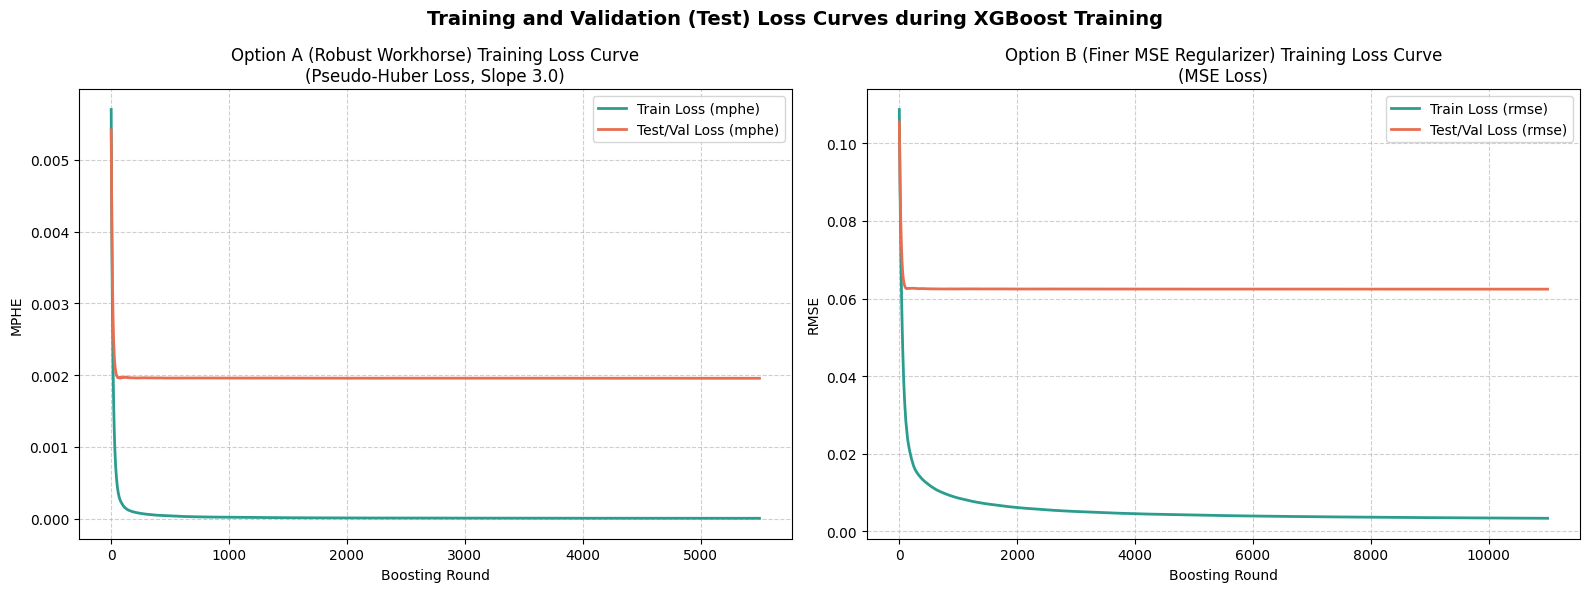

Saved step-by-step training loss history to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-eval-2.0\loss_curves.csv


In [6]:
# Extract loss metrics
metric_A = list(evals_A["validation_0"].keys())[0] # mphe
train_loss_A = evals_A["validation_0"][metric_A]
test_loss_A = evals_A["validation_1"][metric_A]

metric_B = list(evals_B["validation_0"].keys())[0] # rmse
train_loss_B = evals_B["validation_0"][metric_B]
test_loss_B = evals_B["validation_1"][metric_B]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Option A
axes[0].plot(train_loss_A, label=f"Train Loss ({metric_A})", color="#2a9d8f", linewidth=2)
axes[0].plot(test_loss_A, label=f"Test/Val Loss ({metric_A})", color="#e76f51", linewidth=2)
axes[0].set_xlabel("Boosting Round")
axes[0].set_ylabel(metric_A.upper())
axes[0].set_title("Option A (Robust Workhorse) Training Loss Curve\n(Pseudo-Huber Loss, Slope 3.0)")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Plot Option B
axes[1].plot(train_loss_B, label=f"Train Loss ({metric_B})", color="#2a9d8f", linewidth=2)
axes[1].plot(test_loss_B, label=f"Test/Val Loss ({metric_B})", color="#e76f51", linewidth=2)
axes[1].set_xlabel("Boosting Round")
axes[1].set_ylabel(metric_B.upper())
axes[1].set_title("Option B (Finer MSE Regularizer) Training Loss Curve\n(MSE Loss)")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.suptitle("Training and Validation (Test) Loss Curves during XGBoost Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "loss_curves.png", dpi=300)
plt.show()

# Save step-by-step training losses to CSV
loss_df_A = pd.DataFrame({
    "step": range(len(train_loss_A)),
    "option_a_train_loss": train_loss_A,
    "option_a_test_loss": test_loss_A
})
loss_df_B = pd.DataFrame({
    "step": range(len(train_loss_B)),
    "option_b_train_loss": train_loss_B,
    "option_b_test_loss": test_loss_B
})
loss_df = pd.merge(loss_df_A, loss_df_B, on="step", how="outer")
loss_df.to_csv(out_dir / "loss_curves.csv", index=False)
print(f"Saved step-by-step training loss history to: {out_dir / 'loss_curves.csv'}")



# Section 6: Metrics Comparison and Tables

We compute and present training and test split performance metrics side-by-side.

In [7]:
# Prepare overall metrics dataframe
metrics_summary_data = []
for split_name, metrics in [
    ("Option A Train (Unweighted)", metrics_A_train),
    ("Option A Test (Unweighted)", metrics_A_test),
    ("Option B Train (Unweighted)", metrics_B_train),
    ("Option B Test (Unweighted)", metrics_B_test)
]:
    row = {"Configuration": split_name}
    row.update(metrics)
    metrics_summary_data.append(row)

summary_df = pd.DataFrame(metrics_summary_data)
print("\n===== COMPARATIVE PERFORMANCE SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format
}))

summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)


===== COMPARATIVE PERFORMANCE SUMMARY =====
              Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Option A Train (Unweighted) 0.9990 0.0034 0.0034 +0.0000 0.0021   0.0013  0.9995
 Option A Test (Unweighted) 0.6468 0.0626 0.0590 -0.0210 0.0470   0.0356  0.8323
Option B Train (Unweighted) 0.9991 0.0034 0.0034 +0.0000 0.0021   0.0013  0.9995
 Option B Test (Unweighted) 0.6487 0.0624 0.0588 -0.0210 0.0469   0.0361  0.8333


# Section 7: Residual Plots and Year-by-Year Performance

We analyze residuals overall and year-by-year, saving metrics to `metrics_by_year.csv` and plotting yearly performance.

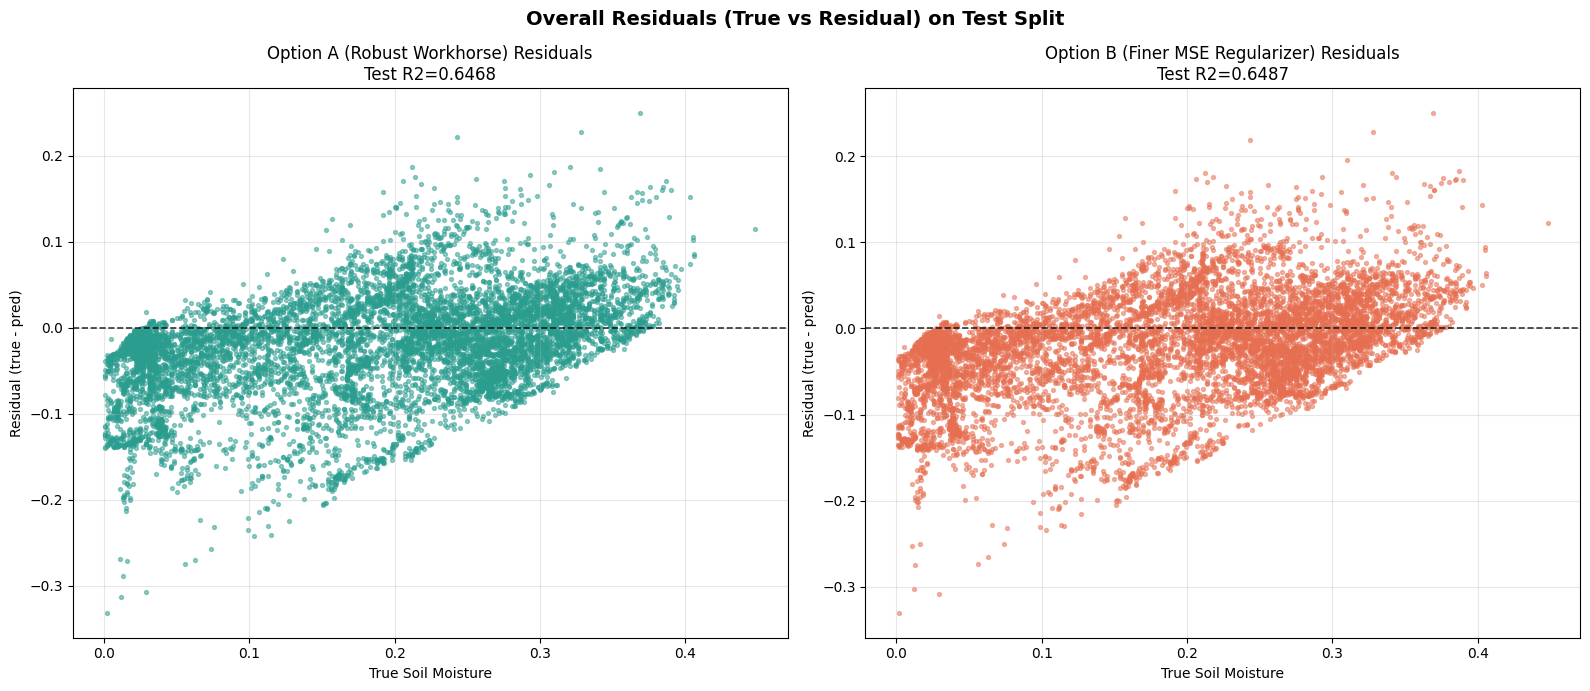

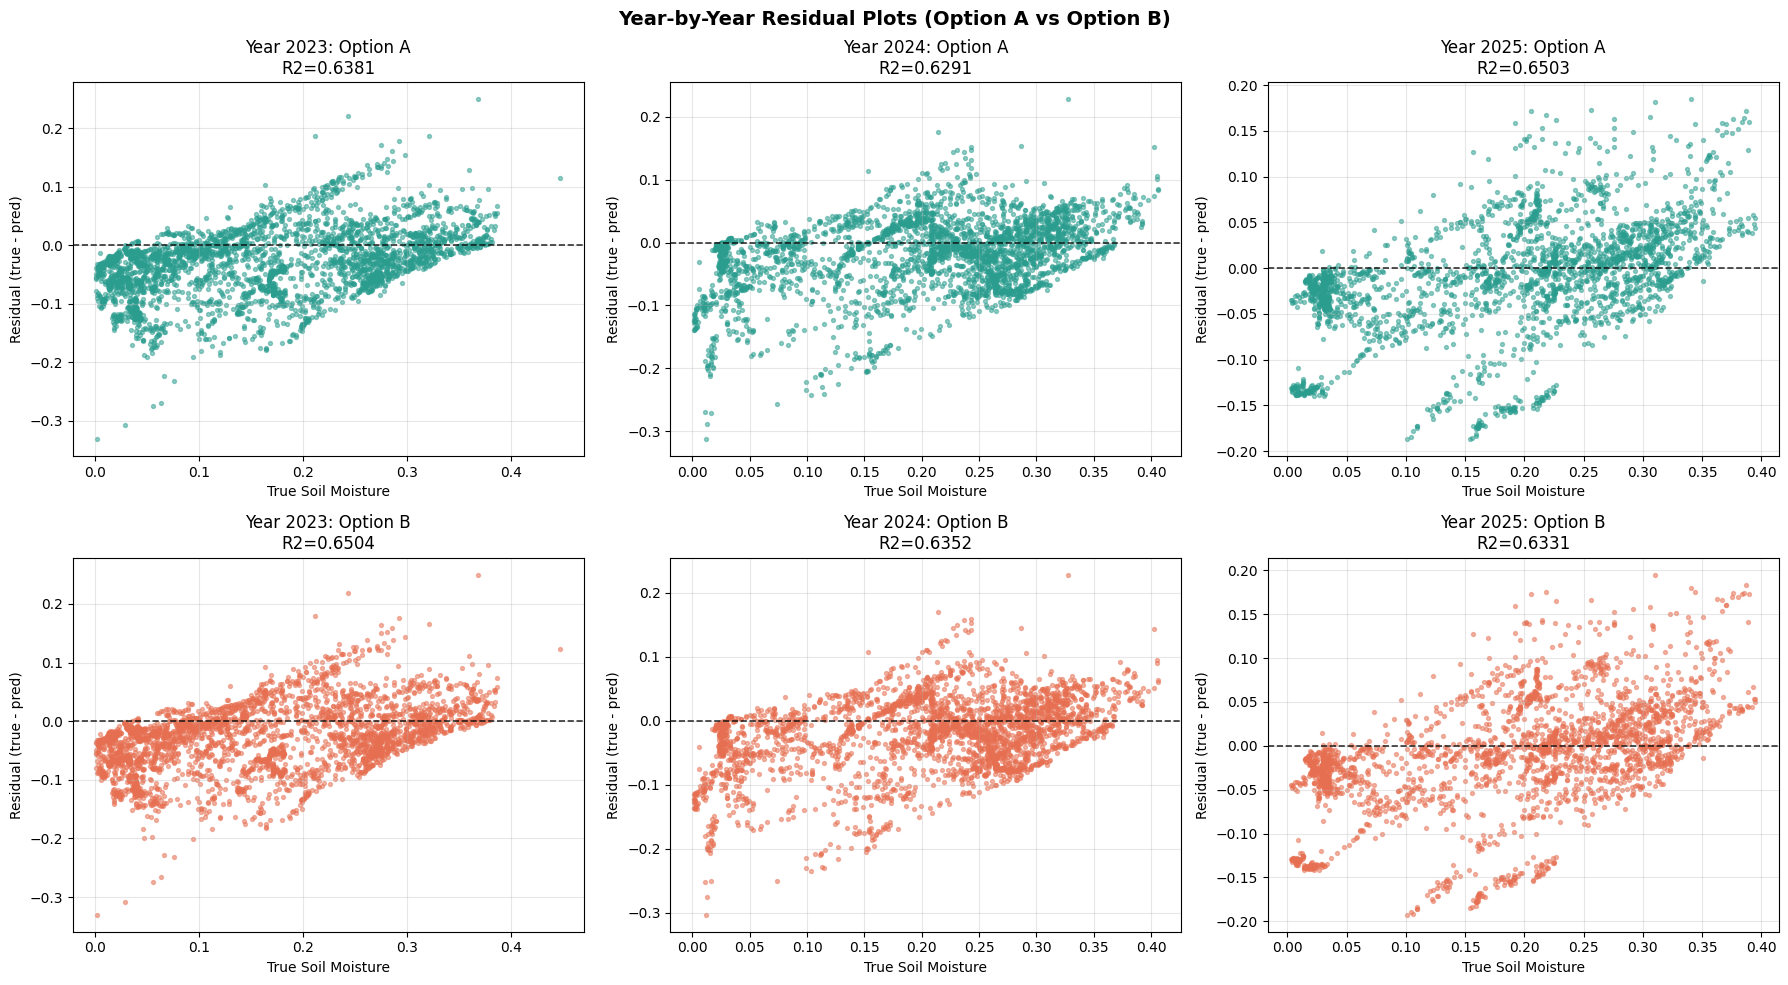


===== YEAR-BY-YEAR COMPARATIVE SUMMARY =====

--- Test Year: 2023 ---
                   Configuration  Year     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
     Option A (Robust Workhorse)  2023 0.6381 0.0647 0.0568 -0.0311 0.0504   0.0407  0.8511
Option B (Finer MSE Regularizer)  2023 0.6504 0.0636 0.0560 -0.0301 0.0497   0.0409  0.8550

--- Test Year: 2024 ---
                   Configuration  Year     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
     Option A (Robust Workhorse)  2024 0.6291 0.0608 0.0575 -0.0198 0.0447   0.0336  0.8277
Option B (Finer MSE Regularizer)  2024 0.6352 0.0603 0.0566 -0.0208 0.0442   0.0337  0.8321

--- Test Year: 2025 ---
                   Configuration  Year     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
     Option A (Robust Workhorse)  2025 0.6503 0.0619 0.0612 -0.0093 0.0454   0.0326  0.8139
Option B (Finer MSE Regularizer)  2025 0.6331 0.0634 0.0627 -0.0095 0.0466   0.0335  0.8043


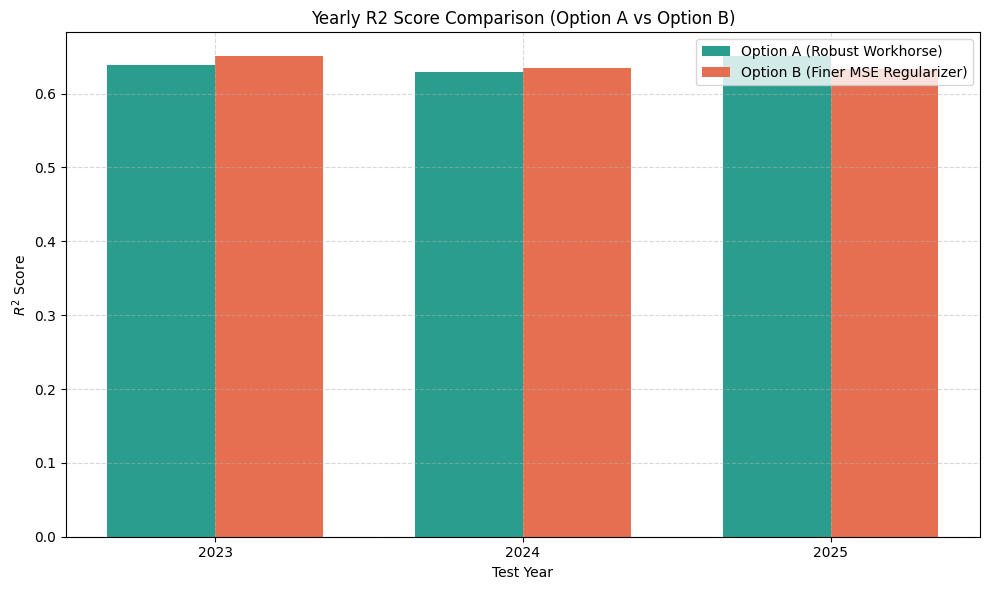

In [8]:
# Overall residual scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

res_A = y_test - pred_A_test
res_B = y_test - pred_B_test

# Option A
axes[0].scatter(y_test, res_A, s=8, alpha=0.5, color="#2a9d8f")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Option A (Robust Workhorse) Residuals\nTest R2={metrics_A_test['R2']:.4f}")
axes[0].grid(alpha=0.3)

# Option B
axes[1].scatter(y_test, res_B, s=8, alpha=0.5, color="#e76f51")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Option B (Finer MSE Regularizer) Residuals\nTest R2={metrics_B_test['R2']:.4f}")
axes[1].grid(alpha=0.3)

plt.suptitle("Overall Residuals (True vs Residual) on Test Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png", dpi=300)
plt.show()

# Year-by-Year Analysis
test_years = sorted(test_df["year"].unique())
yearly_metrics_data = []

fig, axes = plt.subplots(2, len(test_years), figsize=(18, 10))

for idx_yr, yr in enumerate(test_years):
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    # Predict for each model
    pred_A_yr = np.asarray(model_A.predict(df_yr[FEATURE_SET_V3])).ravel()
    pred_B_yr = np.asarray(model_B.predict(df_yr[FEATURE_SET_V3])).ravel()
    
    res_A_yr = y_test_yr - pred_A_yr
    res_B_yr = y_test_yr - pred_B_yr
    
    metrics_A_yr = compute_metrics(y_test_yr, pred_A_yr)
    metrics_B_yr = compute_metrics(y_test_yr, pred_B_yr)
    
    # Save metrics
    for config_name, metrics in [
        ("Option A (Robust Workhorse)", metrics_A_yr),
        ("Option B (Finer MSE Regularizer)", metrics_B_yr)
    ]:
        row = {"Configuration": config_name, "Year": int(yr)}
        row.update(metrics)
        yearly_metrics_data.append(row)
        
    # Plot Option A Year
    axes[0, idx_yr].scatter(y_test_yr, res_A_yr, s=8, alpha=0.5, color="#2a9d8f")
    axes[0, idx_yr].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    axes[0, idx_yr].set_xlabel("True Soil Moisture")
    axes[0, idx_yr].set_ylabel("Residual (true - pred)")
    axes[0, idx_yr].set_title(f"Year {int(yr)}: Option A\nR2={metrics_A_yr['R2']:.4f}")
    axes[0, idx_yr].grid(alpha=0.3)
    
    # Plot Option B Year
    axes[1, idx_yr].scatter(y_test_yr, res_B_yr, s=8, alpha=0.5, color="#e76f51")
    axes[1, idx_yr].axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    axes[1, idx_yr].set_xlabel("True Soil Moisture")
    axes[1, idx_yr].set_ylabel("Residual (true - pred)")
    axes[1, idx_yr].set_title(f"Year {int(yr)}: Option B\nR2={metrics_B_yr['R2']:.4f}")
    axes[1, idx_yr].grid(alpha=0.3)

plt.suptitle("Year-by-Year Residual Plots (Option A vs Option B)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png", dpi=300)
plt.show()

# Save yearly metrics
yearly_summary_df = pd.DataFrame(yearly_metrics_data)
print("\n===== YEAR-BY-YEAR COMPARATIVE SUMMARY =====")
for yr in test_years:
    df_yr_m = yearly_summary_df[yearly_summary_df["Year"] == int(yr)]
    print(f"\n--- Test Year: {int(yr)} ---")
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot R2 score comparisons by year
fig, ax = plt.subplots(figsize=(10, 6))
years_plot = [int(y) for y in test_years]

r2_A_vals = [yearly_summary_df[(yearly_summary_df["Configuration"] == "Option A (Robust Workhorse)") & (yearly_summary_df["Year"] == y)]["R2"].values[0] for y in years_plot]
r2_B_vals = [yearly_summary_df[(yearly_summary_df["Configuration"] == "Option B (Finer MSE Regularizer)") & (yearly_summary_df["Year"] == y)]["R2"].values[0] for y in years_plot]

width = 0.35
ax.bar([y - width/2 for y in years_plot], r2_A_vals, width, label="Option A (Robust Workhorse)", color="#2a9d8f")
ax.bar([y + width/2 for y in years_plot], r2_B_vals, width, label="Option B (Finer MSE Regularizer)", color="#e76f51")

ax.set_xticks(years_plot)
ax.set_xticklabels([str(y) for y in years_plot])
ax.set_xlabel("Test Year")
ax.set_ylabel("$R^2$ Score")
ax.set_title("Yearly R2 Score Comparison (Option A vs Option B)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "r2_by_year.png", dpi=300)
plt.show()